In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from typing import Tuple
from datetime import datetime

#add path path to data folder using sys.path
sys.path.append('../data_process/')

from data_process import load_dataset
from processors.demographics import get_demographics_data, get_demographic_summary, print_demographic_summary
from processors.measurements import get_bmi_data, get_bmi_statistics
from processors.cbc import get_cbc_data, get_cbc_subject_statistics, get_cbc_overall_statistics, CBC_REFERENCE_INTERVALS

# Load your data
df = pd.read_csv('../data/subject_cbc_events.csv')
df.head()

plt.style.use('seaborn')  # Use a nicer style
plt.rcParams['figure.figsize'] = (8, 4)  # Set smaller default figure size
plt.rcParams['axes.titlesize'] = 11  # Smaller title size
plt.rcParams['axes.labelsize'] = 10  # Smaller label size
plt.rcParams['xtick.labelsize'] = 9  # Smaller tick labels
plt.rcParams['ytick.labelsize'] = 9
# make the font Work Sans
plt.rcParams['font.family'] = 'Work Sans'
# make the dpi 200
plt.rcParams['figure.dpi'] = 200
# make the color palettes hues from the color palette
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=sns.color_palette('husl', 8))


OSError: [Errno 6] Device not configured

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading data...

Demographic Analysis

Analysis of Age
---------------

Summary Statistics:
   count: 1052355.00
    mean: 57.55
     std: 15.93
     min: 18.21
     25%: 47.00
     50%: 59.79
     75%: 69.14
     max: 88.86


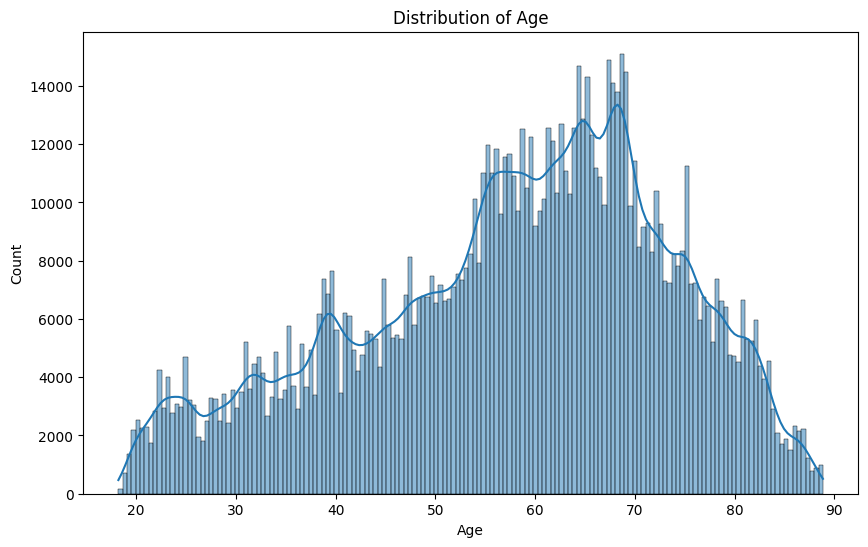


Analysis of Gender
------------------

Value Counts:
                   M: 591,002 ( 56.2%)
                   F: 461,353 ( 43.8%)


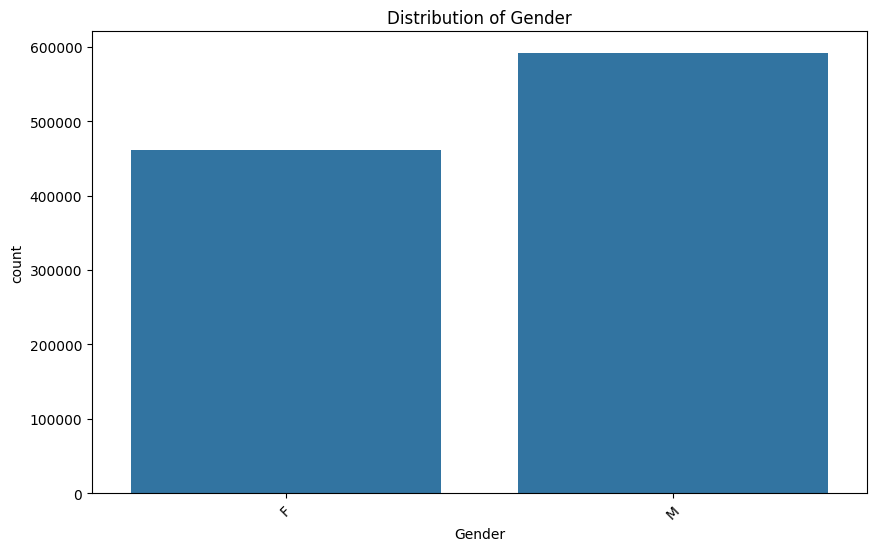


Analysis of Race
----------------

Summary Statistics:
   count: 1052355.00
    mean: 4.17
     std: 1.28
     min: 1.00
     25%: 3.00
     50%: 5.00
     75%: 5.00
     max: 5.00


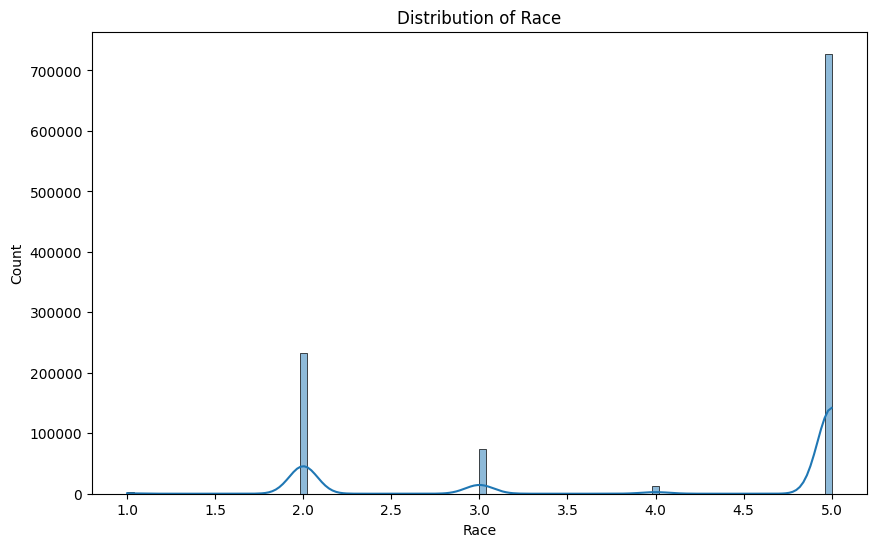


Analysis of Ethnicity
---------------------

Value Counts:
        Not Hispanic: 996,316 ( 94.7%)
            Hispanic: 56,039 (  5.3%)


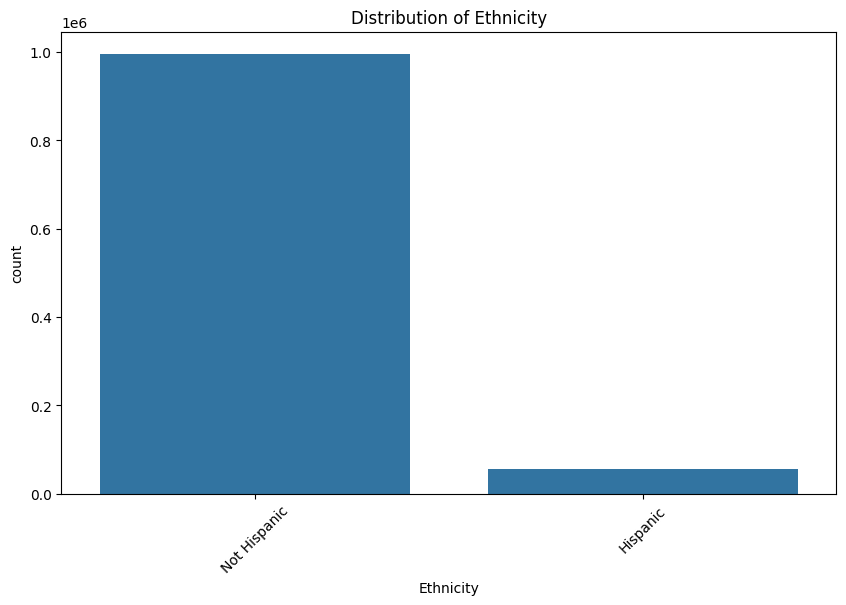


BMI Analysis
------------

Analysis of BMI
---------------

Summary Statistics:
   count: 1052355.00
    mean: 26.55
     std: 6.25
     min: 11.46
     25%: 22.34
     50%: 25.60
     75%: 29.59
     max: 78.45


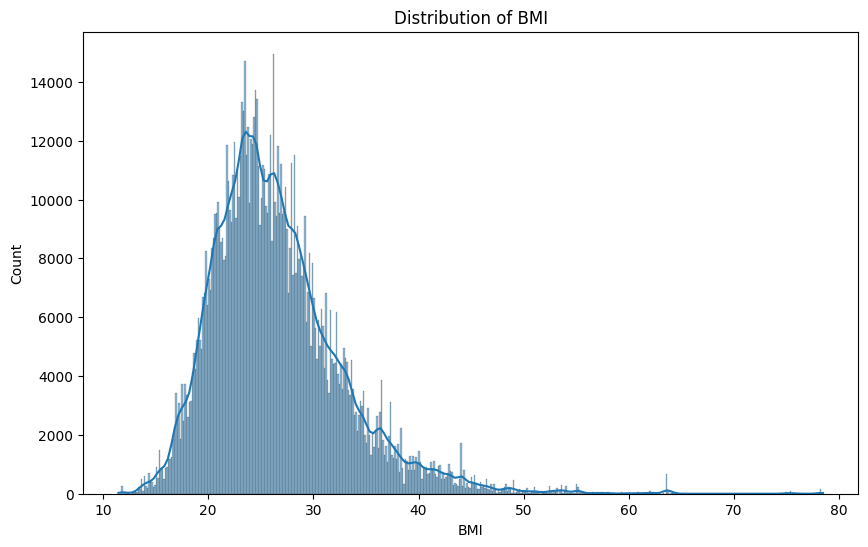


BMI Categories:
         Normal: 421,842 ( 40.1%)
     Overweight: 326,772 ( 31.1%)
        Obesity: 155,084 ( 14.7%)
 Severe Obesity: 57,121 (  5.4%)
    Underweight: 53,877 (  5.1%)
 Morbid Obesity: 37,659 (  3.6%)


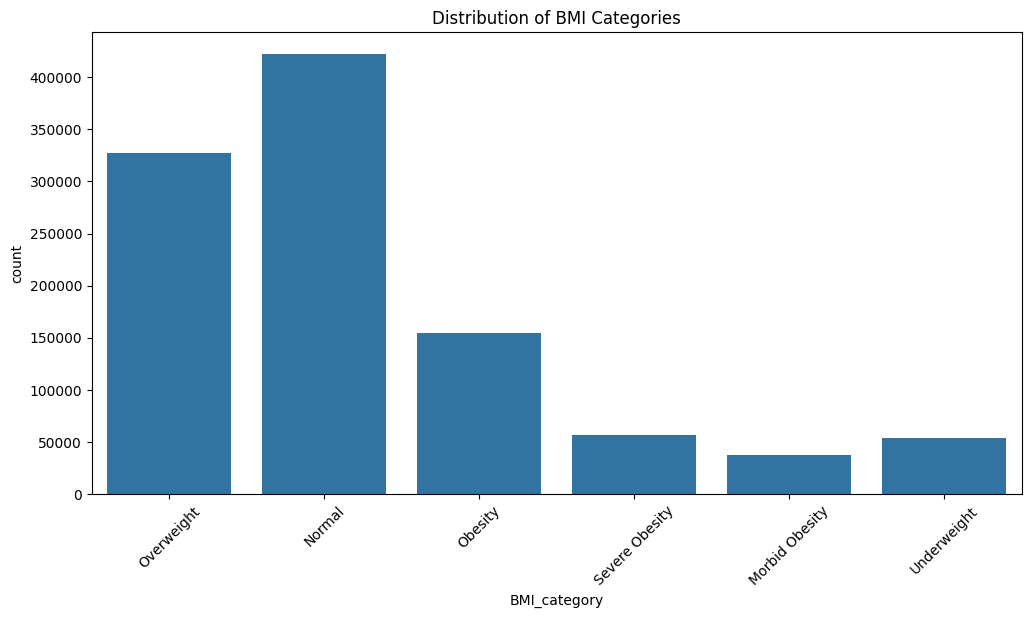


Analysis of RBC
---------------

Summary Statistics:
   count: 130711.00
    mean: 3.55
     std: 0.80
     min: 0.77
     25%: 2.92
     50%: 3.48
     75%: 4.14
     max: 8.18


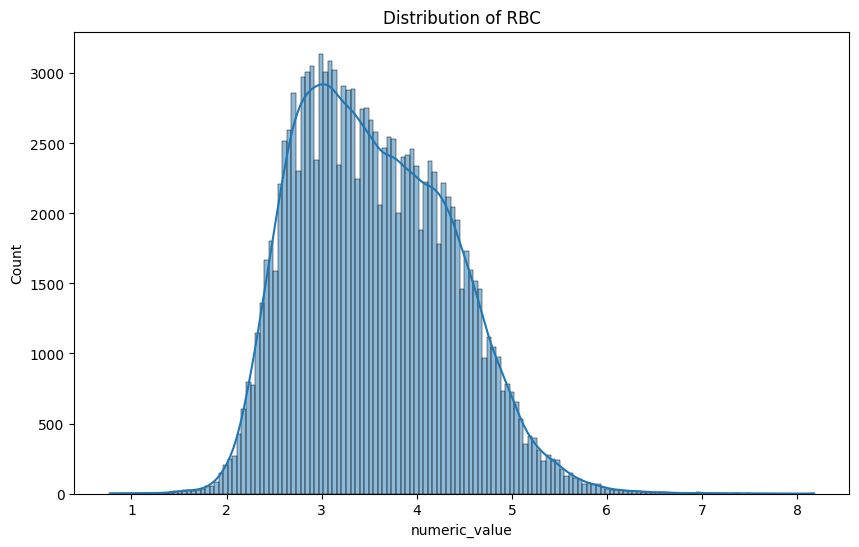


Analysis of MCH
---------------

Summary Statistics:
   count: 129860.00
    mean: 30.40
     std: 2.90
     min: 15.00
     25%: 28.90
     50%: 30.50
     75%: 32.10
     max: 47.80


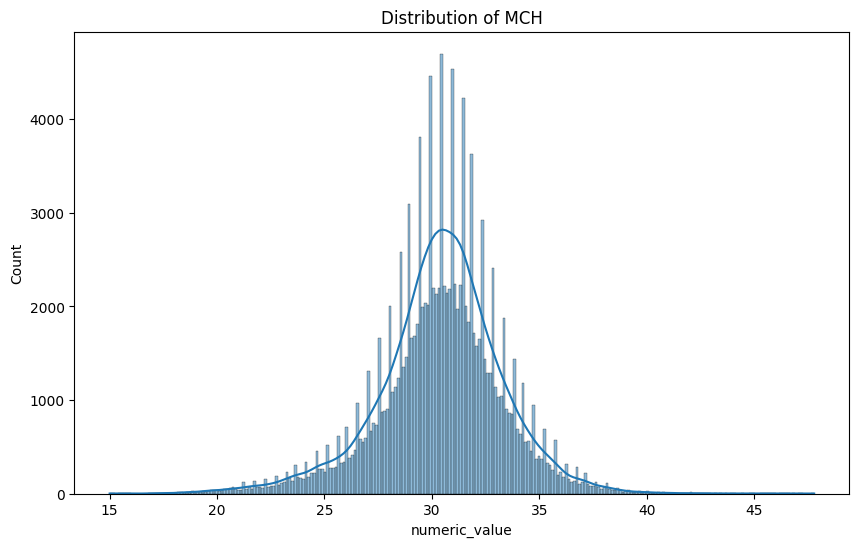


Analysis of MCHC
----------------

Summary Statistics:
   count: 130610.00
    mean: 33.18
     std: 1.42
     min: 23.50
     25%: 32.30
     50%: 33.30
     75%: 34.20
     max: 43.50


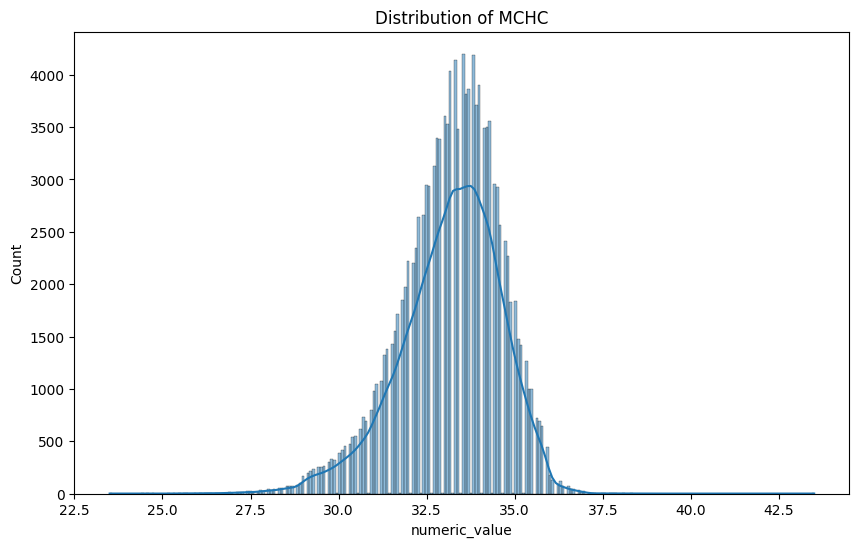


Analysis of RDW
---------------

Summary Statistics:
   count: 130597.00
    mean: 16.30
     std: 3.22
     min: 9.80
     25%: 14.00
     50%: 15.60
     75%: 17.80
     max: 57.70


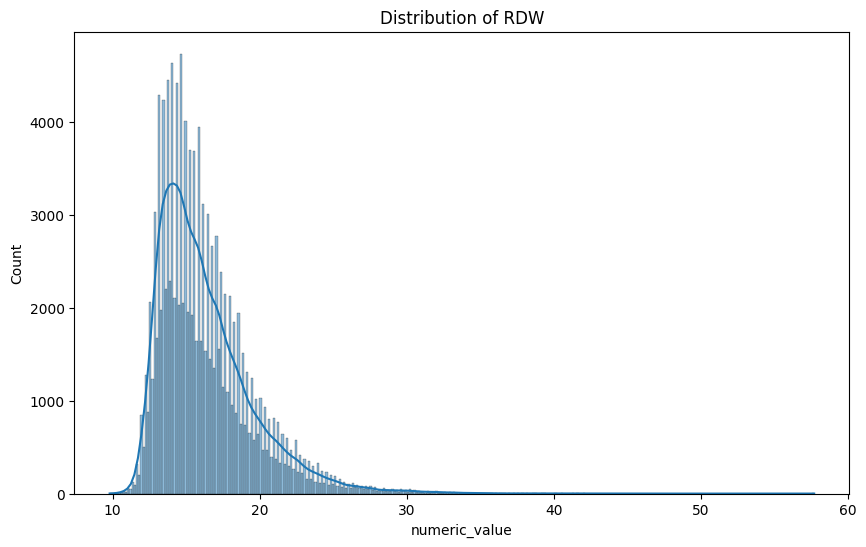


Analysis of MCV
---------------

Summary Statistics:
   count: 130644.00
    mean: 91.64
     std: 7.50
     min: 52.10
     25%: 87.50
     50%: 91.50
     75%: 96.00
     max: 141.00


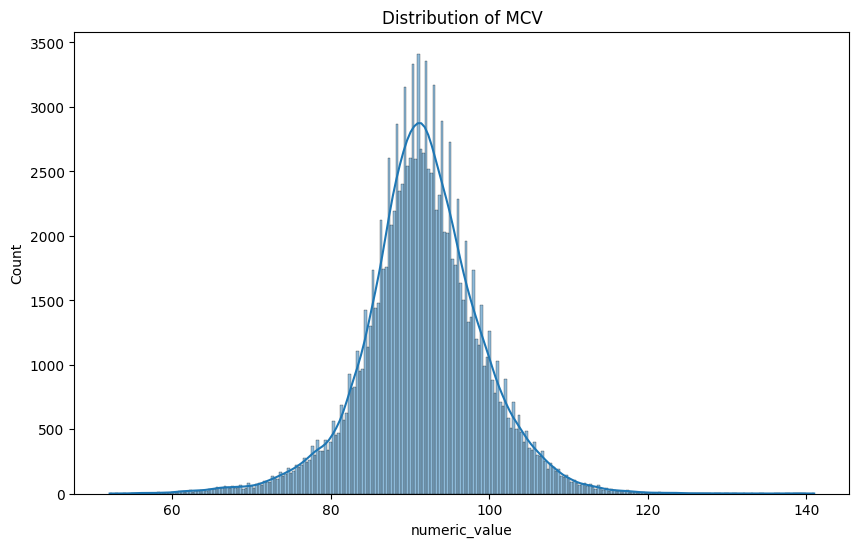


Analysis of HGB
---------------

Summary Statistics:
   count: 131690.00
    mean: 10.74
     std: 2.31
     min: 2.40
     25%: 8.90
     50%: 10.50
     75%: 12.40
     max: 20.90


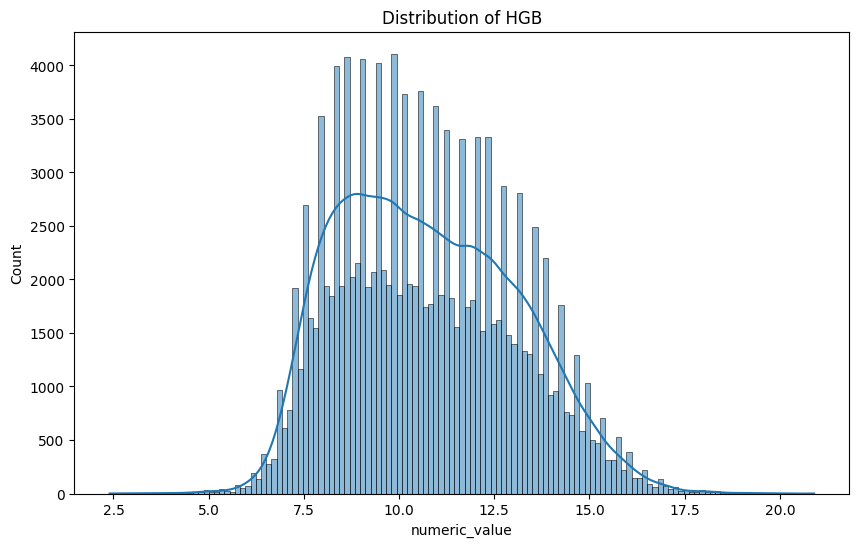


Analysis of PLT
---------------

Summary Statistics:
   count: 131744.00
    mean: 203.83
     std: 125.02
     min: 1.00
     25%: 122.00
     50%: 193.00
     75%: 265.00
     max: 1543.00


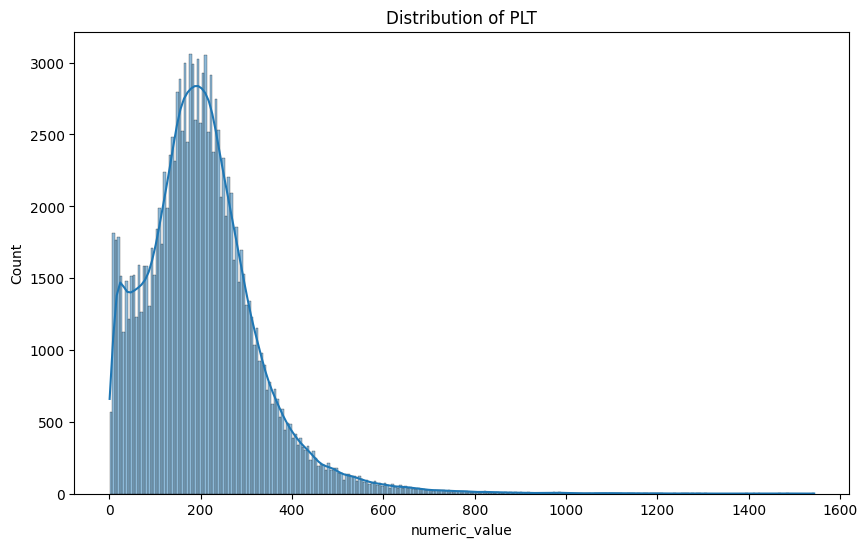


Analysis of HCT
---------------

Summary Statistics:
   count: 135008.00
    mean: 32.30
     std: 6.84
     min: 7.25
     25%: 26.80
     50%: 31.70
     75%: 37.50
     max: 67.20


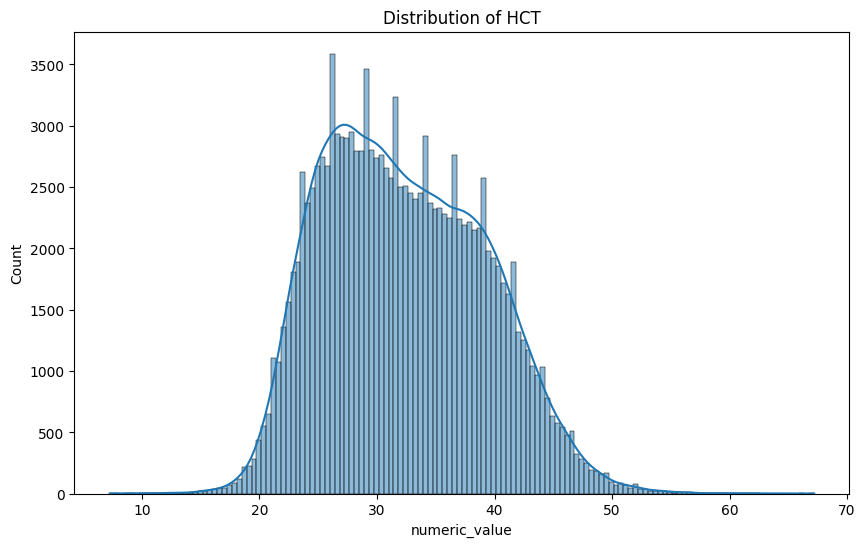


Analysis of WBC
---------------

Summary Statistics:
   count: 1491.00
    mean: 1249.02
     std: 3567.16
     min: 0.10
     25%: 5.60
     50%: 9.00
     75%: 15.00
     max: 40900.00


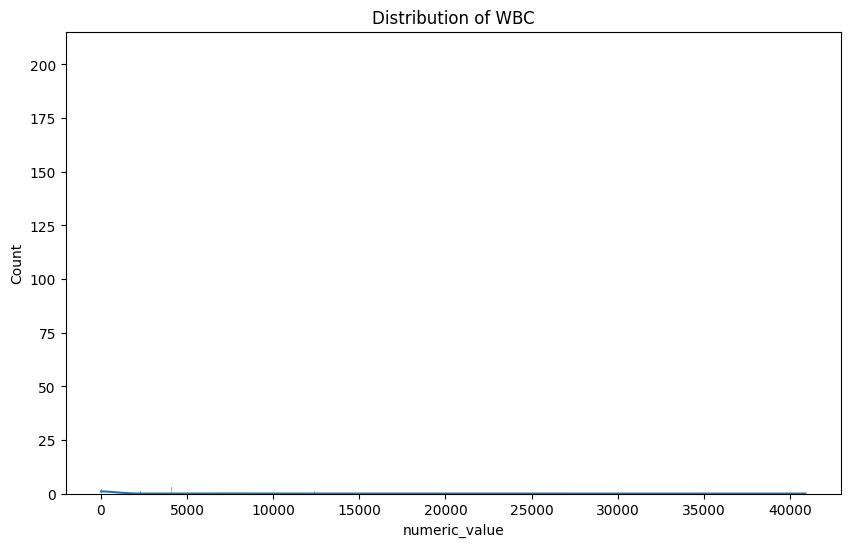

In [28]:
# Setup and imports
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from typing import Tuple
from datetime import datetime

# Add data_process to path
sys.path.append('../data_process/')

from data_process import load_dataset
from processors.demographics import get_demographics_data, get_demographic_summary
from processors.measurements import get_bmi_data, get_bmi_statistics
from processors.cbc import get_cbc_data, get_cbc_subject_statistics, get_cbc_overall_statistics

def analyze_variable(df: pd.DataFrame, variable: str, plot: bool = True):
    """
    Analyze a single variable with summary statistics and optional plot.
    """
    print(f"\nAnalysis of {variable}")
    print("-" * (len(variable) + 12))
    
    # Get basic statistics
    if pd.api.types.is_numeric_dtype(df[variable]):
        print("\nSummary Statistics:")
        stats = df[variable].describe()
        for stat, value in stats.items():
            print(f"{stat:>8}: {value:.2f}")
            
        if plot:
            plt.figure(figsize=(10, 6))
            sns.histplot(data=df, x=variable, kde=True)
            plt.title(f'Distribution of {variable}')
            plt.show()
            
    else:
        print("\nValue Counts:")
        counts = df[variable].value_counts()
        total = len(df)
        for value, count in counts.items():
            percentage = 100 * count / total
            print(f"{value:>20}: {count:>6,d} ({percentage:>5.1f}%)")
            
        if plot:
            plt.figure(figsize=(10, 6))
            sns.countplot(data=df, x=variable)
            plt.title(f'Distribution of {variable}')
            plt.xticks(rotation=45)
            plt.show()

def analyze_bmi(df: pd.DataFrame):
    """Analyze BMI data with visualizations."""
    print("\nBMI Analysis")
    print("-" * 12)
    
    # Basic BMI statistics
    analyze_variable(df, 'BMI')
    
    # BMI categories
    print("\nBMI Categories:")
    bmi_cats = df['BMI_category'].value_counts()
    total = len(df)
    for cat, count in bmi_cats.items():
        print(f"{cat:>15}: {count:>6,d} ({100 * count / total:>5.1f}%)")
    
    # Plot BMI category distribution
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='BMI_category')
    plt.title('Distribution of BMI Categories')
    plt.xticks(rotation=45)
    plt.show()

def analyze_cbc(df: pd.DataFrame, code: str, reference_range: Tuple[float, float] = None):
    """
    Analyze CBC measurements for a specific code.
    
    Args:
        df: DataFrame with CBC data
        code: CBC code to analyze
        reference_range: Optional tuple of (lower, upper) reference range
    """
    code_data = df[df['code'] == code]
    
    print(f"\nAnalysis of {code}")
    print("-" * (len(code) + 12))
    
    # Basic statistics
    stats = code_data['numeric_value'].describe()
    print("\nSummary Statistics:")
    for stat, value in stats.items():
        print(f"{stat:>8}: {value:.2f}")
    
    # Reference range analysis if provided
    if reference_range:
        low, high = reference_range
        in_range = code_data[
            (code_data['numeric_value'] >= low) & 
            (code_data['numeric_value'] <= high)
        ]
        pct_in_range = 100 * len(in_range) / len(code_data)
        print(f"\nReference Range ({low:.1f} - {high:.1f}):")
        print(f"In range: {len(in_range):,d} ({pct_in_range:.1f}%)")
    
    # Plot distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=code_data, x='numeric_value', kde=True)
    if reference_range:
        plt.axvline(low, color='r', linestyle='--', label='Reference Range')
        plt.axvline(high, color='r', linestyle='--')
    plt.title(f'Distribution of {code}')
    plt.show()

# Load and process data
print("Loading data...")
df = pd.read_csv('../data/subject_cbc_events.csv')

# Demographic analysis
print("\nDemographic Analysis")
for feature in ['Age', 'Gender', 'Race', 'Ethnicity']:
    analyze_variable(df, feature)

# BMI analysis
analyze_bmi(df)

# CBC analysis
cbc_codes = df['code'].unique()
for code in cbc_codes:
    analyze_cbc(df, code)